<a href="https://colab.research.google.com/github/maratisiri/ASSIGNMENT/blob/STATICS/RMDS_Image_Segmentation_ADE20K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
Tesla T4


# **Create notebook sections**

In [ ]:
# Image Segmentation using ADE20K Dataset

## 1. Install Libraries

## 2. Import Libraries

## 3. Load Dataset

## 4. Explore Dataset (EDA)

## 5. Data Preprocessing

## 6. Build Segmentation Model

## 7. Train Model

## 8. Evaluate Model

## 9. Test on New Images

## 10. Conclusions

# **Install required packages**

In [2]:
!pip install -q pycocotools
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.5 MB/s eta 0:00:00


# **Import libraries**

In [3]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision

from pycocotools.coco import COCO

# **Check the dataset**

In [4]:
import os

print(os.listdir())

['.config', 'RMDS_segmentation_dataset_ADE20K_350.zip', 'sample_data']


In [7]:
!unzip -q RMDS_segmentation_dataset_ADE20K_350.zip

In [8]:
import os
print(os.listdir())

['.config', 'val', 'RMDS_segmentation_dataset_ADE20K_350.zip', 'train', 'test', 'instances_val.json', 'instances_train.json', '__MACOSX', 'sample_data']


# **Inspect the dataset**

In [9]:
import os

print("Number of training images:", len(os.listdir("train")))
print("Number of validation images:", len(os.listdir("val")))
print("Number of test images:", len(os.listdir("test")))

Number of training images: 350
Number of validation images: 350
Number of test images: 30


# **Then inspect the training folder**

In [10]:
train_files = sorted(os.listdir("train"))

print("First 10 files:")
for file in train_files[:10]:
    print(file)

First 10 files:
ADE_val_00000003.jpg
ADE_val_00000004.jpg
ADE_val_00000010.jpg
ADE_val_00000012.jpg
ADE_val_00000013.jpg
ADE_val_00000014.jpg
ADE_val_00000016.jpg
ADE_val_00000019.jpg
ADE_val_00000028.jpg
ADE_val_00000031.jpg


# **Check the dataset size**

In [11]:
import os

print("Training images:", len(os.listdir("train")))
print("Validation images:", len(os.listdir("val")))
print("Test images:", len(os.listdir("test")))

Training images: 350
Validation images: 350
Test images: 30


# **Read the annotation file**

In [12]:
import json

with open("instances_train.json", "r") as f:
    train_json = json.load(f)

print(train_json.keys())

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


# **Find the category IDs**

In [13]:
categories = train_json["categories"]

print("Total categories:", len(categories))

for category in categories:
    print(category)

Total categories: 100
{'id': 1, 'name': 'bed'}
{'id': 2, 'name': 'windowpane'}
{'id': 3, 'name': 'cabinet'}
{'id': 4, 'name': 'person'}
{'id': 5, 'name': 'door'}
{'id': 6, 'name': 'table'}
{'id': 7, 'name': 'curtain'}
{'id': 8, 'name': 'chair'}
{'id': 9, 'name': 'car'}
{'id': 10, 'name': 'painting'}
{'id': 11, 'name': 'sofa'}
{'id': 12, 'name': 'shelf'}
{'id': 13, 'name': 'mirror'}
{'id': 14, 'name': 'armchair'}
{'id': 15, 'name': 'seat'}
{'id': 16, 'name': 'fence'}
{'id': 17, 'name': 'desk'}
{'id': 18, 'name': 'wardrobe'}
{'id': 19, 'name': 'lamp'}
{'id': 20, 'name': 'bathtub'}
{'id': 21, 'name': 'railing'}
{'id': 22, 'name': 'cushion'}
{'id': 23, 'name': 'box'}
{'id': 24, 'name': 'column'}
{'id': 25, 'name': 'signboard'}
{'id': 26, 'name': 'chest of drawers'}
{'id': 27, 'name': 'counter'}
{'id': 28, 'name': 'sink'}
{'id': 29, 'name': 'fireplace'}
{'id': 30, 'name': 'refrigerator'}
{'id': 31, 'name': 'stairs'}
{'id': 32, 'name': 'case'}
{'id': 33, 'name': 'pool table'}
{'id': 34, 'nam

In [14]:
print("Number of images:", len(train_json["images"]))
print("Number of annotations:", len(train_json["annotations"]))

Number of images: 350
Number of annotations: 5111


In [15]:
train_json["images"][0]

{'file_name': 'ADE_val_00001597.jpg', 'width': 683, 'id': 21806, 'height': 512}

# **Step 1: Build a mapping for the four target classes**

In [16]:
# Target classes required by the assignment

TARGET_CLASSES = {
    4: "person",
    9: "car",
    40: "book",
    59: "airplane"
}

print(TARGET_CLASSES)

{4: 'person', 9: 'car', 40: 'book', 59: 'airplane'}


# **Step 2: Count how many annotations belong to each class**

In [17]:
from collections import Counter

category_counter = Counter()

for ann in train_json["annotations"]:
    if ann["category_id"] in TARGET_CLASSES:
        category_counter[ann["category_id"]] += 1

print("Training annotations:\n")

for cid, count in category_counter.items():
    print(f"{TARGET_CLASSES[cid]} : {count}")

Training annotations:

car : 689
person : 1084
airplane : 13
book : 155


# **Step 3: Create a simple bar chart**

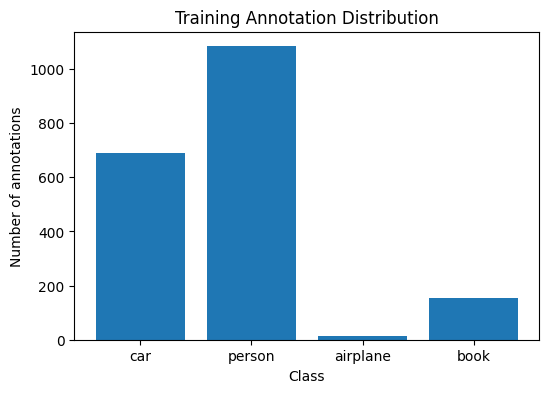

In [18]:
import matplotlib.pyplot as plt

names = [TARGET_CLASSES[k] for k in category_counter.keys()]
counts = [category_counter[k] for k in category_counter.keys()]

plt.figure(figsize=(6,4))
plt.bar(names, counts)

plt.title("Training Annotation Distribution")
plt.xlabel("Class")
plt.ylabel("Number of annotations")

plt.show()

# **Connect images with their annotations**

In [19]:
from collections import defaultdict

# Group annotations by image ID
image_annotations = defaultdict(list)

for ann in train_json["annotations"]:
    image_annotations[ann["image_id"]].append(ann)

print("Images with annotations:", len(image_annotations))

Images with annotations: 350


# **Now inspect one image and its annotations**

In [20]:
sample_image = train_json["images"][0]

print("Image information:")
print(sample_image)

print("\nNumber of annotations:",
      len(image_annotations[sample_image["id"]]))

Image information:
{'file_name': 'ADE_val_00001597.jpg', 'width': 683, 'id': 21806, 'height': 512}

Number of annotations: 21


# **Next, inspect only the target classes**

In [21]:
for ann in image_annotations[sample_image["id"]]:
    if ann["category_id"] in TARGET_CLASSES:
        print(
            f"Class: {TARGET_CLASSES[ann['category_id']]} | "
            f"Category ID: {ann['category_id']} | "
            f"Area: {ann['area']:.1f}"
        )

Class: person | Category ID: 4 | Area: 392.0
Class: person | Category ID: 4 | Area: 655.0


# **preprocessing:**

# **Step 1: Import COCO tools**

In [22]:
from pycocotools.coco import COCO
from pycocotools import mask as maskUtils

# **Step 2: Load the annotation file with COCO**

In [23]:
coco = COCO("instances_train.json")

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


# **Step 3: Check one image**

In [24]:
img_id = coco.getImgIds()[0]

img_info = coco.loadImgs(img_id)[0]

print(img_info)

{'file_name': 'ADE_val_00001597.jpg', 'width': 683, 'id': 21806, 'height': 512}


# **Step 4: Find annotations for this image**

In [25]:
ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

print("Total annotations:", len(anns))

Total annotations: 21


# **Step 5: Display only the four required classes**

In [26]:
for ann in anns:
    if ann["category_id"] in TARGET_CLASSES:
        print(
            f"Class: {TARGET_CLASSES[ann['category_id']]}",
            "| Area:", ann["area"]
        )

Class: person | Area: 392
Class: person | Area: 655
